In [1]:
import pandas as pd

# check the difference between original sold data and filled sold data
filled = pd.read_csv("Dataset/CRMLSSold_Data/CRMLSSold202401_filled.csv")
original = pd.read_csv("Dataset/CRMLSSold_Data/CRMLSSold202401.csv")
print(f"Original: {original.shape}")
print(f"filled: {filled.shape}")
print(original.isnull().sum())
print(filled.isnull().sum())
list = pd.read_csv("Dataset/CRMLSListing_Data/CRMLSListing202401.csv")
print(list.columns)

Original: (17976, 80)
filled: (17958, 80)
BuyerAgentAOR                       7
ListAgentAOR                        7
Flooring                         7860
ViewYN                           1760
WaterfrontYN                    17966
                                ...  
AssociationFee                   5692
LotSizeSquareFeet                1815
MiddleOrJuniorSchoolDistrict    17976
OriginatingSystemName               0
OriginatingSystemSubName            0
Length: 80, dtype: int64
Flooring                         7854
ViewYN                           1760
WaterfrontYN                    17948
BasementYN                      17693
PoolPrivateYN                    2511
                                ...  
AssociationFee                   5683
LotSizeSquareFeet                1812
MiddleOrJuniorSchoolDistrict    17958
latfilled                           0
lonfilled                           0
Length: 80, dtype: int64
Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',

In [2]:
import glob
import re

# Select file (prioritize _filled)
all_files = sorted(glob.glob("Dataset/CRMLSSold_Data/CRMLSSold*.csv"))

month_files = {}
for f in all_files:
    match = re.search(r"CRMLSSold(\d{6})", f)
    if match:
        ym = match.group(1)
        if ym not in month_files or "_filled" in f:
            month_files[ym] = f

sold_files = [month_files[ym] for ym in sorted(month_files)]
print(f"Selected {len(sold_files)} files:")
for f in sold_files:
    print(f"  {f}")


Selected 29 files:
  Dataset/CRMLSSold_Data/CRMLSSold202401_filled.csv
  Dataset/CRMLSSold_Data/CRMLSSold202402.csv
  Dataset/CRMLSSold_Data/CRMLSSold202403_filled.csv
  Dataset/CRMLSSold_Data/CRMLSSold202404_filled.csv
  Dataset/CRMLSSold_Data/CRMLSSold202405_filled.csv
  Dataset/CRMLSSold_Data/CRMLSSold202406_filled.csv
  Dataset/CRMLSSold_Data/CRMLSSold202407_filled.csv
  Dataset/CRMLSSold_Data/CRMLSSold202408.csv
  Dataset/CRMLSSold_Data/CRMLSSold202409.csv
  Dataset/CRMLSSold_Data/CRMLSSold202410.csv
  Dataset/CRMLSSold_Data/CRMLSSold202411.csv
  Dataset/CRMLSSold_Data/CRMLSSold202412.csv
  Dataset/CRMLSSold_Data/CRMLSSold202501_filled.csv
  Dataset/CRMLSSold_Data/CRMLSSold202502.csv
  Dataset/CRMLSSold_Data/CRMLSSold202503.csv
  Dataset/CRMLSSold_Data/CRMLSSold202504.csv
  Dataset/CRMLSSold_Data/CRMLSSold202505.csv
  Dataset/CRMLSSold_Data/CRMLSSold202506.csv
  Dataset/CRMLSSold_Data/CRMLSSold202507.csv
  Dataset/CRMLSSold_Data/CRMLSSold202508.csv
  Dataset/CRMLSSold_Data/CRMLSSo

In [3]:
# concatenates all monthly sold files from 2024/01 to 2026/05
sold_parts = []
for f in sold_files:
    df = pd.read_csv(f)
    print(f"{f}: {len(df)} rows")
    sold_parts.append(df)

sold = pd.concat(sold_parts, ignore_index=True)
print(f"\nTotal sold rows after concat: {len(sold)}")
print(f"Shape: {sold.shape}")

Dataset/CRMLSSold_Data/CRMLSSold202401_filled.csv: 17958 rows
Dataset/CRMLSSold_Data/CRMLSSold202402.csv: 19925 rows
Dataset/CRMLSSold_Data/CRMLSSold202403_filled.csv: 23276 rows
Dataset/CRMLSSold_Data/CRMLSSold202404_filled.csv: 24640 rows


/var/folders/6c/f38nm5ns3b76h14156xhrw8c0000gn/T/ipykernel_83379/3241388748.py:4: DtypeWarning: Columns (0: WaterfrontYN, 1: ElementarySchool, 2: BuilderName, 3: CoBuyerAgentFirstName, 4: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


Dataset/CRMLSSold_Data/CRMLSSold202405_filled.csv: 26487 rows
Dataset/CRMLSSold_Data/CRMLSSold202406_filled.csv: 24328 rows
Dataset/CRMLSSold_Data/CRMLSSold202407_filled.csv: 26240 rows
Dataset/CRMLSSold_Data/CRMLSSold202408.csv: 24558 rows
Dataset/CRMLSSold_Data/CRMLSSold202409.csv: 21267 rows
Dataset/CRMLSSold_Data/CRMLSSold202410.csv: 23274 rows
Dataset/CRMLSSold_Data/CRMLSSold202411.csv: 20279 rows
Dataset/CRMLSSold_Data/CRMLSSold202412.csv: 20241 rows
Dataset/CRMLSSold_Data/CRMLSSold202501_filled.csv: 18738 rows
Dataset/CRMLSSold_Data/CRMLSSold202502.csv: 18702 rows
Dataset/CRMLSSold_Data/CRMLSSold202503.csv: 21445 rows
Dataset/CRMLSSold_Data/CRMLSSold202504.csv: 23262 rows
Dataset/CRMLSSold_Data/CRMLSSold202505.csv: 23154 rows


/var/folders/6c/f38nm5ns3b76h14156xhrw8c0000gn/T/ipykernel_83379/3241388748.py:4: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


Dataset/CRMLSSold_Data/CRMLSSold202506.csv: 22883 rows
Dataset/CRMLSSold_Data/CRMLSSold202507.csv: 23646 rows
Dataset/CRMLSSold_Data/CRMLSSold202508.csv: 22972 rows
Dataset/CRMLSSold_Data/CRMLSSold202509.csv: 22443 rows
Dataset/CRMLSSold_Data/CRMLSSold202510.csv: 23233 rows
Dataset/CRMLSSold_Data/CRMLSSold202511.csv: 19088 rows
Dataset/CRMLSSold_Data/CRMLSSold202512.csv: 20538 rows


/var/folders/6c/f38nm5ns3b76h14156xhrw8c0000gn/T/ipykernel_83379/3241388748.py:4: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


Dataset/CRMLSSold_Data/CRMLSSold202601.csv: 16487 rows
Dataset/CRMLSSold_Data/CRMLSSold202602.csv: 19010 rows
Dataset/CRMLSSold_Data/CRMLSSold202603.csv: 23372 rows
Dataset/CRMLSSold_Data/CRMLSSold202604.csv: 24261 rows
Dataset/CRMLSSold_Data/CRMLSSold202605.csv: 24153 rows

Total sold rows after concat: 639860
Shape: (639860, 84)


In [4]:
# listing file
listing_files = sorted(glob.glob("Dataset/CRMLSListing_Data/CRMLSListing*.csv"))
print(f"Selected {len(listing_files)} files:")
for f in listing_files:
    print(f"  {f}")

Selected 29 files:
  Dataset/CRMLSListing_Data/CRMLSListing202401.csv
  Dataset/CRMLSListing_Data/CRMLSListing202402.csv
  Dataset/CRMLSListing_Data/CRMLSListing202403.csv
  Dataset/CRMLSListing_Data/CRMLSListing202404.csv
  Dataset/CRMLSListing_Data/CRMLSListing202405.csv
  Dataset/CRMLSListing_Data/CRMLSListing202406.csv
  Dataset/CRMLSListing_Data/CRMLSListing202407.csv
  Dataset/CRMLSListing_Data/CRMLSListing202408.csv
  Dataset/CRMLSListing_Data/CRMLSListing202409.csv
  Dataset/CRMLSListing_Data/CRMLSListing202410.csv
  Dataset/CRMLSListing_Data/CRMLSListing202411.csv
  Dataset/CRMLSListing_Data/CRMLSListing202412.csv
  Dataset/CRMLSListing_Data/CRMLSListing202501.csv
  Dataset/CRMLSListing_Data/CRMLSListing202502.csv
  Dataset/CRMLSListing_Data/CRMLSListing202503.csv
  Dataset/CRMLSListing_Data/CRMLSListing202504.csv
  Dataset/CRMLSListing_Data/CRMLSListing202505.csv
  Dataset/CRMLSListing_Data/CRMLSListing202506.csv
  Dataset/CRMLSListing_Data/CRMLSListing202507.csv
  Dataset/CR

In [5]:
listing_parts = []
for f in listing_files:
    df = pd.read_csv(f)
    print(f"{f}: {len(df)} rows")
    listing_parts.append(df)

listing = pd.concat(listing_parts, ignore_index=True)
print(f"\nTotal listing rows after concat: {len(listing)}")
print(f"Shape: {listing.shape}")


Dataset/CRMLSListing_Data/CRMLSListing202401.csv: 27454 rows
Dataset/CRMLSListing_Data/CRMLSListing202402.csv: 27447 rows
Dataset/CRMLSListing_Data/CRMLSListing202403.csv: 32282 rows
Dataset/CRMLSListing_Data/CRMLSListing202404.csv: 36503 rows
Dataset/CRMLSListing_Data/CRMLSListing202405.csv: 38796 rows
Dataset/CRMLSListing_Data/CRMLSListing202406.csv: 35893 rows
Dataset/CRMLSListing_Data/CRMLSListing202407.csv: 36340 rows
Dataset/CRMLSListing_Data/CRMLSListing202408.csv: 35305 rows
Dataset/CRMLSListing_Data/CRMLSListing202409.csv: 34625 rows
Dataset/CRMLSListing_Data/CRMLSListing202410.csv: 34730 rows
Dataset/CRMLSListing_Data/CRMLSListing202411.csv: 25128 rows
Dataset/CRMLSListing_Data/CRMLSListing202412.csv: 19417 rows
Dataset/CRMLSListing_Data/CRMLSListing202501.csv: 37469 rows
Dataset/CRMLSListing_Data/CRMLSListing202502.csv: 33983 rows
Dataset/CRMLSListing_Data/CRMLSListing202503.csv: 38492 rows
Dataset/CRMLSListing_Data/CRMLSListing202504.csv: 40187 rows
Dataset/CRMLSListing_Dat

/var/folders/6c/f38nm5ns3b76h14156xhrw8c0000gn/T/ipykernel_83379/3797185844.py:3: DtypeWarning: Columns (0: ElementarySchool, 1: BusinessType, 2: MiddleOrJuniorSchool, 3: HighSchool) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


Dataset/CRMLSListing_Data/CRMLSListing202602.csv: 32884 rows
Dataset/CRMLSListing_Data/CRMLSListing202603.csv: 39153 rows
Dataset/CRMLSListing_Data/CRMLSListing202604.csv: 39020 rows
Dataset/CRMLSListing_Data/CRMLSListing202605.csv: 36717 rows

Total listing rows after concat: 930311
Shape: (930311, 84)


In [6]:
# check the propertyType
print("=== Sold PropertyType ===")
print(sold["PropertyType"].value_counts())
print("\n=== Listing PropertyType ===")
print(listing["PropertyType"].value_counts())

=== Sold PropertyType ===
PropertyType
Residential            430428
ResidentialLease       146532
Land                    20726
ManufacturedInPark      17325
ResidentialIncome       17132
CommercialSale           3980
CommercialLease          3317
BusinessOpportunity       420
Name: count, dtype: int64

=== Listing PropertyType ===
PropertyType
Residential            591980
ResidentialLease       192450
Land                    60609
ResidentialIncome       34575
ManufacturedInPark      26632
CommercialSale          12713
CommercialLease          8370
BusinessOpportunity      2982
Name: count, dtype: int64


In [7]:
# filtered only Residential PropertyType
sold_residential = sold[sold["PropertyType"] == "Residential"].copy()
listing_residential = listing[listing["PropertyType"] == "Residential"].copy()
print(f"Sold before filter:  {len(sold):,} rows")
print(f"Sold after filter:   {len(sold_residential):,} rows")

print(f"Listing before filter: {len(listing):,} rows")
print(f"Listing after filter:  {len(listing_residential):,} rows")

Sold before filter:  639,860 rows
Sold after filter:   430,428 rows
Listing before filter: 930,311 rows
Listing after filter:  591,980 rows


In [8]:
# save it as csv
sold_residential.to_csv("sold_combined_residential.csv", index=False)
listing_residential.to_csv("listing_combined_residential.csv", index=False)
print(f"sold_combined_residential.csv: {len(sold_residential):,} rows")
print(f"listing_combined_residential.csv: {len(listing_residential):,} rows")

sold_combined_residential.csv: 430,428 rows
listing_combined_residential.csv: 591,980 rows


## Data Clean & EDA

In [9]:
display(sold_residential)
display(listing_residential)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,94401,6472.0,NaN,NaN,True,True,NaN,NaN,NaN,NaN
5,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,91950,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN
9,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,91950,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN
28,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,...,93401,0.0,11219.0,NaN,False,False,NaN,NaN,NaN,NaN
29,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,...,95437,NaN,74487.6,NaN,False,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
639828,Wood,True,NaN,NaN,False,3500000.0,1063517703,NaN,2026-05-08,1850000.0,...,93060,NaN,3117589.2,NaN,NaN,NaN,NaN,VenturaCoastal,CRMLS,CRMLS_CRF
639836,Wood,True,NaN,NaN,False,675000.0,1052367803,NaN,2026-05-06,655000.0,...,91345,0.0,7039.0,NaN,NaN,NaN,Southland,Southland,CRMLS,CRMLS_CRM
639838,"Carpet,SeeRemarks,Stone,Wood",NaN,NaN,True,False,35000000.0,1048618285,NaN,2026-05-15,21500000.0,...,94507,3039.0,935669.0,NaN,NaN,NaN,ContraCosta,ContraCosta,CRMLS,CRMLS_CCBE
639852,NaN,False,NaN,NaN,True,499000.0,1020935560,NaN,2026-05-22,400000.0,...,91316,504.0,30457.0,NaN,NaN,NaN,BeverlyHillsGreaterLa,SouthBay,CRMLS,CRMLS_CRM


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
5,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
6,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
930306,570000.0,1154277796,NaN,NaN,NaN,Maria Elena,Robles Reyes,32.725211,-117.010369,1935 Terracina Circle,...,NaN,NaN,1.0,Grossmont Union,91977,NaN,400.00,NaN,NaN,1935 Terracina Circle
930307,1500000.0,1153629738,NaN,NaN,NaN,Thomas,Levin,32.954514,-117.113154,12970 La Tortola,...,NaN,False,2.0,NaN,92129,NaN,NaN,7534.0,NaN,12970 La Tortola
930308,13999999.0,1153102507,NaN,NaN,NaN,Heather,Rocha,NaN,NaN,5516 LA CRESCENTA,...,NaN,False,4.0,NaN,92067,NaN,NaN,168577.0,NaN,5516 LA CRESCENTA
930309,637000.0,1151741919,NaN,NaN,NaN,Griselda,Espinoza,33.944936,-118.268552,327 E 101st Street,...,NaN,False,NaN,NaN,90003,NaN,NaN,5176.0,NaN,327 E 101st Street


In [10]:
# check the row and columns
print("Sold shape:", sold_residential.shape)
print("Listing shape:", listing_residential.shape)
# check the data types
print(sold_residential.dtypes.value_counts())
print(listing_residential.dtypes.value_counts())


Sold shape: (430428, 84)
Listing shape: (591980, 84)
str        43
float64    28
object     10
int64       3
Name: count, dtype: int64
str        45
float64    32
int64       4
object      3
Name: count, dtype: int64


In [11]:
def show_dtypes(df, name):
    print(f"\n{'=' * 50}\n{name}\n{'=' * 50}")
    for dtype in df.dtypes.unique():
        cols = df.select_dtypes(include=[dtype]).columns.tolist()
        print(f"\n{dtype} ({len(cols)} columns):")
        print(cols)


show_dtypes(sold_residential, "SOLD DATA")
show_dtypes(listing_residential, "LISTING DATA")



SOLD DATA

str (43 columns):
['Flooring', 'ListAgentEmail', 'CloseDate', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'PropertyType', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'AssociationFeeFrequency', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'BuilderName', 'PropertySubType', 'SubdivisionName', 'BuyerOfficeAOR', 'BuyerAgencyCompensationType', 'ListingId', 'City', 'ContractStatusChangeDate', 'CoBuyerAgentFirstName', 'PurchaseContractDate', 'ListingContractDate', 'BusinessType', 'StateOrProvince', 'MiddleOrJuniorSchool', 'HighSchool', 'Levels', 'LotSizeDimensions', 'HighSchoolDistrict', 'BuyerAgentAOR', 'ListAgentAOR', 'OriginatingSystemName', 'OriginatingSystemSubName']

object (53 columns):
['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'ListAgentEmail', 'CloseDate', 'ListAg

/var/folders/6c/f38nm5ns3b76h14156xhrw8c0000gn/T/ipykernel_83379/2376053885.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = df.select_dtypes(include=[dtype]).columns.tolist()
/var/folders/6c/f38nm5ns3b76h14156xhrw8c0000gn/T/ipykernel_83379/2376053885.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://p

In [12]:
# missing value analysis
def missing_value_analysis(df, name, threshold=90):
    # count missing value and its percentage
    missing_count = df.isnull().sum()
    missing_pct = (df.isnull().mean() * 100).round(2)

    missing_summary = pd.DataFrame(
        {"missing_count": missing_count, "missing_pct": missing_pct}
    ).sort_values("missing_pct", ascending=False)
    print(f"\n{'=' * 50}\n{name} — Missing Value Summary\n{'=' * 50}")
    print(missing_summary)
    # flagged over 90% pct missing value
    flagged_cols = missing_summary[
        missing_summary["missing_pct"] > threshold
    ].index.tolist()
    print(f"\nColumns flagged with >{threshold}% missing ({len(flagged_cols)}):")
    print(flagged_cols)
    return missing_summary, flagged_cols


sold_missing, sold_flagged = missing_value_analysis(sold_residential, "SOLD DATA")
listing_missing, listing_flagged = missing_value_analysis(
    listing_residential, "LISTING DATA"
)


SOLD DATA — Missing Value Summary
                          missing_count  missing_pct
AboveGradeFinishedArea           430428        100.0
CoveredSpaces                    430428        100.0
TaxAnnualAmount                  430428        100.0
TaxYear                          430428        100.0
ElementarySchoolDistrict         430428        100.0
...                                 ...          ...
PropertyType                          0          0.0
DaysOnMarket                          0          0.0
ListPrice                             0          0.0
CloseDate                             0          0.0
ListingContractDate                   1          0.0

[84 rows x 2 columns]

Columns flagged with >90% missing (15):
['AboveGradeFinishedArea', 'CoveredSpaces', 'TaxAnnualAmount', 'TaxYear', 'ElementarySchoolDistrict', 'FireplacesTotal', 'MiddleOrJuniorSchoolDistrict', 'BusinessType', 'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'LotSizeDimensions', 'BuilderName', 'Bui

## Market Analysis columns


In [13]:
print(sold_residential["WaterfrontYN"].value_counts(dropna=False))
print(sold_residential["BasementYN"].value_counts(dropna=False))
print(sold_residential["BuildingAreaTotal"].value_counts(dropna=False))
print(sold_residential["TaxAnnualAmount"].value_counts(dropna=False))

WaterfrontYN
NaN     430157
True       271
Name: count, dtype: int64
BasementYN
NaN     421991
True      8437
Name: count, dtype: int64
BuildingAreaTotal
NaN       400257
0.0           99
1200.0        70
1500.0        68
1600.0        66
           ...  
3919.0         1
8570.0         1
9698.0         1
5778.0         1
6040.0         1
Name: count, Length: 5028, dtype: int64
TaxAnnualAmount
NaN    430428
Name: count, dtype: int64


### Columns with More Than 90% Missing Values

#### Sold_data

| Column | Recommended Action | Reason |
|---------|--------------------|--------|
| AboveGradeFinishedArea | Drop | Contains more than 90% missing values, leaving too few observations for meaningful analysis. |
| CoveredSpaces | Drop | Highly missing and largely redundant with `GarageSpaces` and `ParkingTotal`. |
| TaxAnnualAmount | Drop | Contains more than 100% missing values, leaving too few observations for meaningful analysis. |
| TaxYear | Drop | Has little value without reliable tax information. |
| ElementarySchoolDistrict | Drop | Extremely sparse and not essential for the current analysis. |
| FireplacesTotal | Drop | Non-core housing feature with excessive missing values. |
| MiddleOrJuniorSchoolDistrict | Drop | Extremely sparse and not required for market analysis. |
| BusinessType | Drop | Not relevant for residential housing market analysis. |
| WaterfrontYN | Review | May influence property value; consider retaining if sufficient valid records exist. |
| BelowGradeFinishedArea | Drop | Highly missing and not essential for this project. |
| BasementYN | Review | Could be useful for price analysis; evaluate before removal. |
| LotSizeDimensions | Drop | `LotSizeSquareFeet` and `LotSizeAcres` already provide similar information. |
| BuilderName | Drop | Metadata field with limited analytical value. |
| BuildingAreaTotal | Review | Compare with `LivingArea` to determine redundancy. |
| CoBuyerAgentFirstName | Drop | Metadata related to agents, not property characteristics. |

#### Listing_Data

| Column | Recommended Action | Reason |
|---------|--------------------|--------|
| TaxAnnualAmount | Drop | Contains more than 90% missing values, providing insufficient data for reliable analysis. |
| FireplacesTotal | Drop | Contains more than 90% missing values and is not a core feature for this analysis. |
| ElementarySchoolDistrict | Drop | Contains more than 90% missing values, limiting its usefulness. |
| TaxYear | Drop | Contains more than 90% missing values and has limited value without reliable tax information. |
| BusinessType | Drop | Contains more than 90% missing values and is not relevant to residential market analysis. |
| MiddleOrJuniorSchoolDistrict | Drop | Contains more than 90% missing values, limiting its usefulness. |
| CoveredSpaces | Drop | Contains more than 90% missing values and overlaps with other parking-related features. |
| AboveGradeFinishedArea | Drop | Contains more than 90% missing values, leaving insufficient observations for analysis. |
| BelowGradeFinishedArea | Drop | Contains more than 90% missing values, leaving insufficient observations for analysis. |
| CoBuyerAgentFirstName | Drop | Metadata field with more than 90% missing values and no analytical value. |
| BuilderName | Drop | Metadata field with more than 90% missing values and limited analytical value. |
| LotSizeDimensions | Drop | Contains more than 90% missing values; similar lot size information is available in other variables. |
| BuildingAreaTotal | Drop | Contains more than 90% missing values, making it unsuitable for reliable analysis. |


In [14]:
# sold_data: define columns to drop
sold_columns_to_drop = [
    "AboveGradeFinishedArea",
    "TaxAnnualAmount",
    "CoveredSpaces",
    "TaxYear",
    "ElementarySchoolDistrict",
    "FireplacesTotal",
    "MiddleOrJuniorSchoolDistrict",
    "BusinessType",
    "BelowGradeFinishedArea",
    "LotSizeDimensions",
    "BuilderName",
    "CoBuyerAgentFirstName",
    "latfilled",
    "lonfilled",
]
sold_columns_to_review = [
    "WaterfrontYN",
    "BasementYN",
    "BuildingAreaTotal",
]
# Make sure only existing columns are dropped
sold_columns_to_drop_existing = [
    col for col in sold_columns_to_drop if col in sold_residential.columns
]
# create new clean dataframe
sold_data_clean = sold_residential.drop(columns=sold_columns_to_drop_existing)
# check
print("Original sold_data shape:", sold_residential.shape)
print("Clean sold_data shape:", sold_data_clean.shape)
print("\nDropped columns:")
print(sold_columns_to_drop_existing)
print("\nReview columns still kept:")
print([col for col in sold_columns_to_review if col in sold_data_clean.columns])

Original sold_data shape: (430428, 84)
Clean sold_data shape: (430428, 70)

Dropped columns:
['AboveGradeFinishedArea', 'TaxAnnualAmount', 'CoveredSpaces', 'TaxYear', 'ElementarySchoolDistrict', 'FireplacesTotal', 'MiddleOrJuniorSchoolDistrict', 'BusinessType', 'BelowGradeFinishedArea', 'LotSizeDimensions', 'BuilderName', 'CoBuyerAgentFirstName', 'latfilled', 'lonfilled']

Review columns still kept:
['WaterfrontYN', 'BasementYN', 'BuildingAreaTotal']


In [15]:
# listing_data: define columns to drop
listing_columns_to_drop = [
    "TaxAnnualAmount",
    "FireplacesTotal",
    "ElementarySchoolDistrict",
    "TaxYear",
    "BusinessType",
    "MiddleOrJuniorSchoolDistrict",
    "CoveredSpaces",
    "AboveGradeFinishedArea",
    "BelowGradeFinishedArea",
    "CoBuyerAgentFirstName",
    "BuilderName",
    "LotSizeDimensions",
    "BuildingAreaTotal",
]
# create a cleaned dataset
listing_data_clean = listing_residential.drop(columns=listing_columns_to_drop)
# check
print("Original listing_data shape:", listing_residential.shape)
print("Clean listing_data shape:", listing_data_clean.shape)
print("\nDropped columns:")
print(listing_columns_to_drop)

Original listing_data shape: (591980, 84)
Clean listing_data shape: (591980, 71)

Dropped columns:
['TaxAnnualAmount', 'FireplacesTotal', 'ElementarySchoolDistrict', 'TaxYear', 'BusinessType', 'MiddleOrJuniorSchoolDistrict', 'CoveredSpaces', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea', 'CoBuyerAgentFirstName', 'BuilderName', 'LotSizeDimensions', 'BuildingAreaTotal']


In [16]:
print(sold_data_clean.columns)
print(listing_data_clean.columns)

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation',
       'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusCh

In [17]:
display(sold_data_clean.head(5))
display(listing_data_clean.head(5))

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,False,1.0,Other,94401,6472.0,NaN,NaN,NaN,NaN,NaN
5,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,False,2.0,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,False,2.0,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN
28,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,...,False,3.0,San Luis Coastal Unified,93401,0.0,11219.0,NaN,NaN,NaN,NaN
29,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,...,NaN,2.0,NaN,95437,NaN,74487.6,NaN,NaN,NaN,NaN


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,177861.0,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,2220 Avenue Of The Stars 2704
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,5300.0,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,16 Palisades
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,9404.0,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,1615 Waverly Road
5,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,58232.0,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,2250 Indian Creek Road
6,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,2250.0,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,317 E. Bayfront


In [18]:
# sold_data_clean
# Separate market analysis fields from metadata fields
# metadata columns
metadata_columns = [
    "ListingKey",
    "ListingKeyNumeric",
    "ListingId",
    "ListAgentEmail",
    "ListAgentFirstName",
    "ListAgentLastName",
    "ListAgentFullName",
    "CoListAgentFirstName",
    "CoListAgentLastName",
    "BuyerAgentMlsId",
    "BuyerAgentFirstName",
    "BuyerAgentLastName",
    "ListOfficeName",
    "BuyerOfficeName",
    "CoListOfficeName",
    "BuyerOfficeAOR",
    "BuyerAgentAOR",
    "ListAgentAOR",
    "StreetNumberNumeric",
    "UnparsedAddress",
    "OriginatingSystemName",
    "OriginatingSystemSubName",
]
# Keep only metadata columns that exist in sold_data_clean
metadata_columns = [col for col in metadata_columns if col in sold_data_clean.columns]
# Everything else becomes market analysis columns
market_analysis_columns = [
    col for col in sold_data_clean.columns if col not in metadata_columns
]
# Create separate dataframes
sold_market_df = sold_data_clean[market_analysis_columns].copy()
sold_metadata_df = sold_data_clean[metadata_columns].copy()
# check data info
print("Market analysis shape:", sold_market_df.shape)
print("Metadata shape:", sold_metadata_df.shape)

Market analysis shape: (430428, 48)
Metadata shape: (430428, 22)


In [21]:
# check the listing data duplicate columns
for col in listing_data_clean.columns:
    if col.endswith(".1"):
        original = col[:-2]

        if original in listing_data_clean.columns:
            same = listing_data_clean[original].equals(listing_data_clean[col])
            print(f"{original:<20} == {col:<20} : {same}")
# delete duplicate columns
duplicate_columns = [col for col in listing_data_clean.columns if col.endswith(".1")]
listing_data_clean = listing_data_clean.drop(columns=duplicate_columns)
print("Dropped duplicated columns:")
print(duplicate_columns)
print("New shape:", listing_data_clean.shape)
print(listing_data_clean.columns)

Dropped duplicated columns:
[]
New shape: (591980, 60)
Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       

In [22]:
# listing_data_clean
# Separate market analysis fields from metadata fields
# metadata columns
metadata_columns = [
    "ListingKey",
    "ListingKeyNumeric",
    "ListingId",
    "ListAgentEmail",
    "ListAgentFirstName",
    "ListAgentLastName",
    "ListAgentFullName",
    "CoListAgentFirstName",
    "CoListAgentLastName",
    "BuyerAgentMlsId",
    "BuyerAgentFirstName",
    "BuyerAgentLastName",
    "ListOfficeName",
    "BuyerOfficeName",
    "CoListOfficeName",
    "BuyerOfficeAOR",
    "BuyerAgencyCompensationType",
    "StreetNumberNumeric",
    "UnparsedAddress",
]
# Keep only metadata columns that exist
metadata_columns = [
    col for col in metadata_columns if col in listing_data_clean.columns
]
# Everything else is market analysis
market_analysis_columns = [
    col for col in listing_data_clean.columns if col not in metadata_columns
]
# Create separate dataframe
listing_metadata_df = listing_data_clean[metadata_columns].copy()
listing_market_df = listing_data_clean[market_analysis_columns].copy()
print("Market analysis shape:", listing_market_df.shape)
print("Metadata shape:", listing_metadata_df.shape)

Market analysis shape: (591980, 41)
Metadata shape: (591980, 19)


In [24]:
# check dataframe
display(sold_market_df.head(5))
display(sold_metadata_df.head(5))
display(listing_market_df.head(5))
display(listing_metadata_df.head(5))

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,CloseDate,ClosePrice,Latitude,Longitude,...,HighSchool,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,2024-01-26,240000.0,37.566106,-122.327954,...,NaN,NaN,NaN,NaN,False,1.0,Other,94401,6472.0,NaN
5,NaN,False,NaN,NaN,False,759900.0,2024-01-05,815000.0,32.659315,-117.096922,...,NaN,Two,NaN,NaN,False,2.0,NaN,91950,NaN,NaN
9,NaN,False,NaN,NaN,False,739900.0,2024-01-05,810000.0,32.659284,-117.097174,...,NaN,Two,NaN,NaN,False,2.0,NaN,91950,NaN,NaN
28,NaN,True,NaN,NaN,False,2100000.0,2024-01-02,2100000.0,35.277199,-120.646786,...,NaN,Two,11219.00,3.0,False,3.0,San Luis Coastal Unified,93401,0.0,11219.0
29,Tile,True,NaN,NaN,False,1950000.0,2024-01-22,1950000.0,39.419080,-123.814842,...,NaN,Two,1.71,NaN,NaN,2.0,NaN,95437,NaN,74487.6


,ListingKey,ListingKeyNumeric,ListingId,ListAgentEmail,ListAgentFirstName,ListAgentLastName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,...,ListOfficeName,BuyerOfficeName,CoListOfficeName,BuyerOfficeAOR,BuyerAgentAOR,ListAgentAOR,StreetNumberNumeric,UnparsedAddress,OriginatingSystemName,OriginatingSystemSubName
0,551985747,551985747,ML81865679,jwachter@cbnorcal.com,Joan,Wachter,Joan Wachter,NaN,NaN,ML5090968,...,Coldwell Banker Realty,Bay Area Senior Services,NaN,MLSListings,NaN,NaN,1.0,1 Baldwin Avenue 411,NaN,NaN
5,522107581,522107581,210014555,mdarwich12@gmail.com,Michael,Darwich,Michael Darwich,NaN,NaN,SAND-606727,...,Berkshire Hathaway HomeServices California Pro...,FOSTER HAMILTON Real Estate,NaN,SanDiego,NaN,NaN,2811.0,2811 C Avenue,NaN,NaN
9,510919001,510919001,210008330,mdarwich12@gmail.com,Michael,Darwich,Michael Darwich,NaN,NaN,SAND-606727,...,Berkshire Hathaway HomeServices California Pro...,FOSTER HAMILTON Real Estate,NaN,SanDiego,NaN,NaN,2812.0,2812 C Avenue,NaN,NaN
28,1067652762,1067652762,NS24001417,jenniferarielkennedy@gmail.com,Jennifer,Kennedy,Jennifer Kennedy,NaN,NaN,NS02093802,...,Home & Ranch Sotheby's Intl,Home & Ranch Sotheby's Intl,NaN,NorthSanLuisObispo,NaN,NaN,2054.0,2054 Fixlini Street,NaN,NaN
29,1063453216,1063453216,C1-10456,kira@mendosir.com,Kira,Meade,Kira Meade,NaN,NaN,VCR-cmdeedeethomas,...,Mendo Sotheby's International Realty,West Coast Property Management and Sales,NaN,CoastalMendocino,NaN,NaN,31451.0,31451 Bay View Avenue,NaN,NaN


,OriginalListPrice,CloseDate,ClosePrice,Latitude,Longitude,PropertyType,LivingArea,ListPrice,DaysOnMarket,AssociationFeeFrequency,...,HighSchool,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet
2,1340000.0,NaN,NaN,34.052207,-118.408445,Residential,1301.0,1340000.0,127,Monthly,...,NaN,One,177861.0,NaN,False,NaN,NaN,90067,2105.00,177861.0
3,2500000.0,NaN,NaN,33.496363,-117.691677,Residential,2788.0,2500000.0,1,Monthly,...,NaN,Two,5300.0,0.0,False,3.0,Capistrano Unified,92677,254.00,5300.0
4,3150000.0,NaN,NaN,34.119345,-118.111254,Residential,3250.0,3150000.0,1,NaN,...,NaN,Two,9404.0,NaN,NaN,2.0,NaN,91108,NaN,9404.0
5,3090000.0,NaN,NaN,33.984057,-117.802819,Residential,7456.0,3090000.0,0,Monthly,...,Diamond Bar,ThreeOrMore,58232.0,1.0,False,4.0,Walnut Valley Unified,91765,295.95,58232.0
6,12725000.0,NaN,NaN,33.607583,-117.887743,Residential,2321.0,12725000.0,2,NaN,...,Corona Del Mar,ThreeOrMore,2250.0,3.0,False,2.0,Newport Mesa Unified,92662,0.00,2250.0


,ListingKey,ListingKeyNumeric,ListingId,ListAgentEmail,ListAgentFirstName,ListAgentLastName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,ListOfficeName,BuyerOfficeName,CoListOfficeName,BuyerOfficeAOR,BuyerAgencyCompensationType,StreetNumberNumeric,UnparsedAddress
2,1074973329,1074973329,24389291,haleh360@Gmail.com,Haleh,Dowlatshahi,Haleh Dowlatshahi,NaN,NaN,NaN,NaN,NaN,Rodeo Realty- Brentwood,NaN,NaN,NaN,Item1,2220.0,2220 Avenue Of The Stars 2704
3,1074954552,1074954552,AR24091628,Reneechen@yourhomesoldguaranteed.com,Renee,Chen,Renee Chen,NaN,NaN,NaN,NaN,NaN,Your Home Sold Guaranteed Realty,NaN,NaN,NaN,Item1,16.0,16 Palisades
4,1074936537,1074936537,P1-17547,anader@dppre.com,Margaret,Nader,Margaret Nader,NaN,NaN,NaN,NaN,NaN,COMPASS,NaN,NaN,NaN,Item1,1615.0,1615 Waverly Road
5,1074917818,1074917818,OC24091496,QIANYU0607@GMAIL.COM,QIANYU,GUAN,QIANYU GUAN,NaN,NaN,NaN,NaN,NaN,"Signature One Realty Group, Inc",NaN,NaN,NaN,Item1,2250.0,2250 Indian Creek Road
6,1074143166,1074143166,NP24085020,jeff.williams@pacificsir.com,Jeff,Williams,Jeff Williams,NaN,NaN,NaN,NaN,NaN,Pacific Sotheby's Int'l Realty,NaN,NaN,NaN,Item1,317.0,317 E. Bayfront


### Numeric Distribution


ClosePrice
Missing Values : 2 (0.00%)

Summary Statistics


count    4.304260e+05
mean     1.193110e+06
std      6.174206e+06
min      0.000000e+00
1%       2.020000e+05
5%       3.400000e+05
25%      5.750000e+05
50%      8.250000e+05
75%      1.300000e+06
95%      2.850000e+06
99%      5.575000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

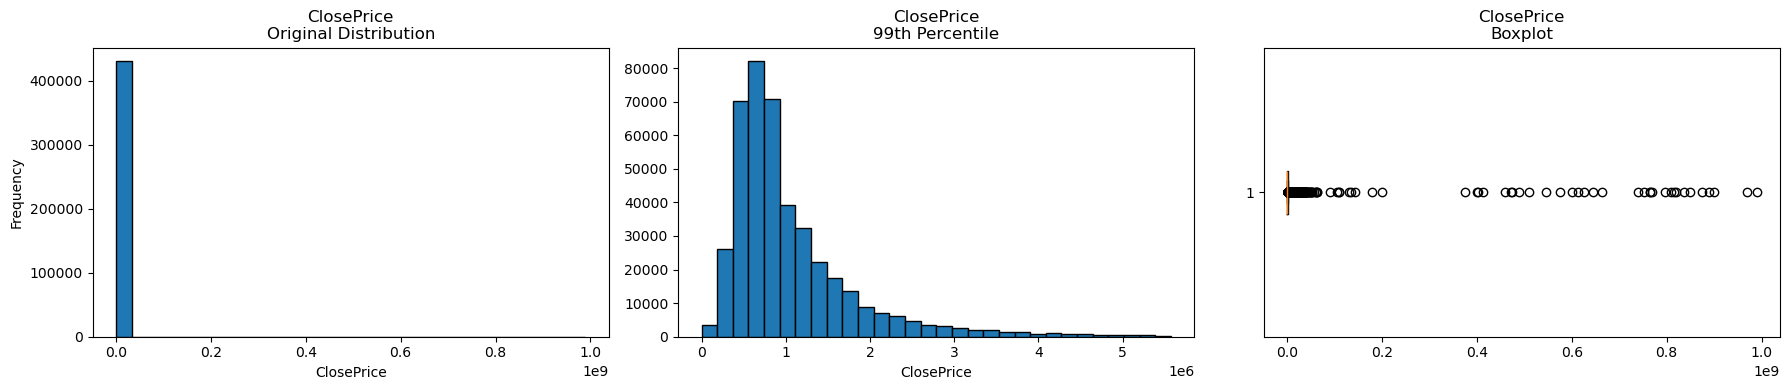

Number of Outliers (IQR): 32,115
Lower Bound: -512,500.00
Upper Bound: 2,387,500.00


ListPrice
Missing Values : 0 (0.00%)

Summary Statistics


count    4.304280e+05
mean     1.141725e+06
std      1.357905e+06
min      5.250000e+02
1%       2.149000e+05
5%       3.459000e+05
25%      5.780000e+05
50%      8.190000e+05
75%      1.295000e+06
95%      2.860000e+06
99%      5.700000e+06
max      1.375000e+08
Name: ListPrice, dtype: float64

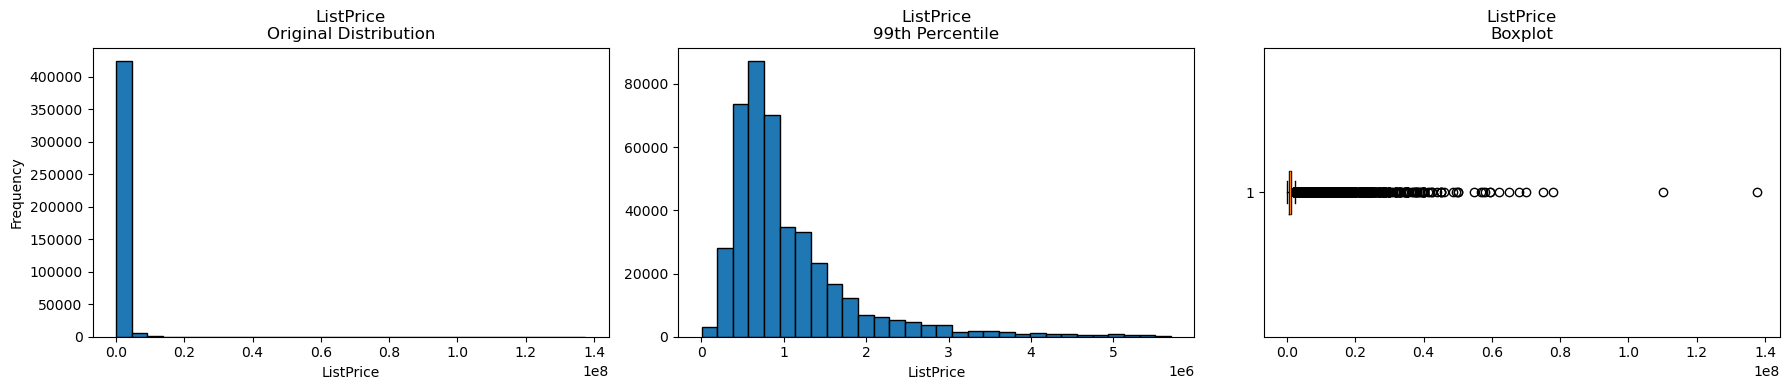

Number of Outliers (IQR): 32,425
Lower Bound: -497,500.00
Upper Bound: 2,370,500.00


OriginalListPrice
Missing Values : 789 (0.18%)

Summary Statistics


count    4.296390e+05
mean     1.226547e+06
std      6.686826e+06
min      0.000000e+00
1%       2.100000e+05
5%       3.499000e+05
25%      5.850000e+05
50%      8.280000e+05
75%      1.299000e+06
95%      2.900000e+06
99%      5.995000e+06
max      1.390000e+09
Name: OriginalListPrice, dtype: float64

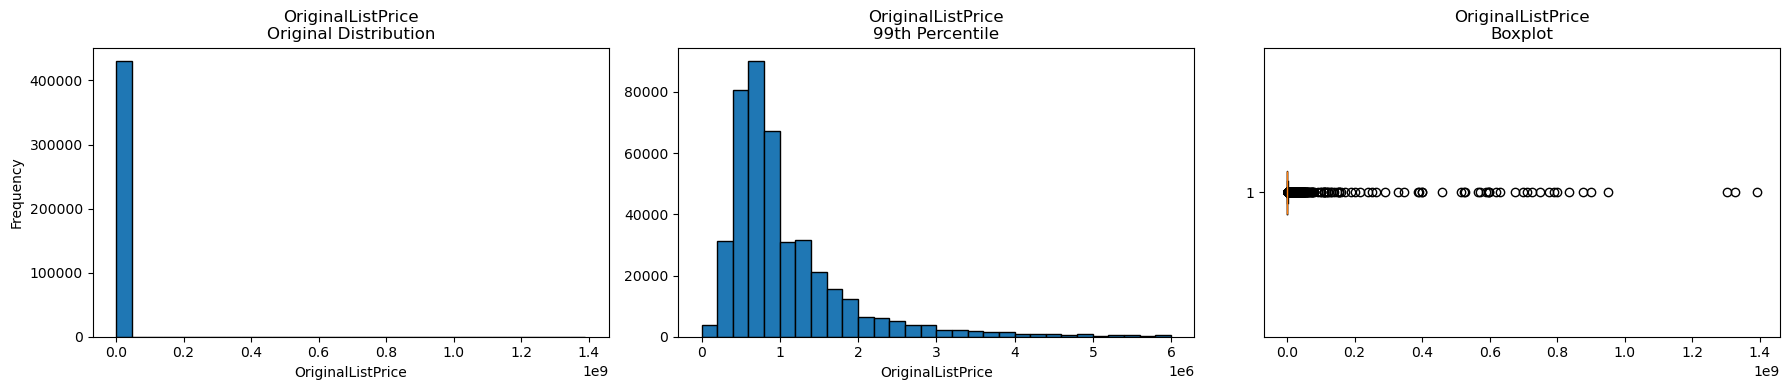

Number of Outliers (IQR): 33,656
Lower Bound: -486,000.00
Upper Bound: 2,370,000.00


LivingArea
Missing Values : 245 (0.06%)

Summary Statistics


count    4.301830e+05
mean     1.904040e+03
std      2.596853e+04
min      0.000000e+00
1%       6.050000e+02
5%       8.400000e+02
25%      1.248000e+03
50%      1.644000e+03
75%      2.221000e+03
95%      3.562000e+03
99%      5.283180e+03
max      1.702132e+07
Name: LivingArea, dtype: float64

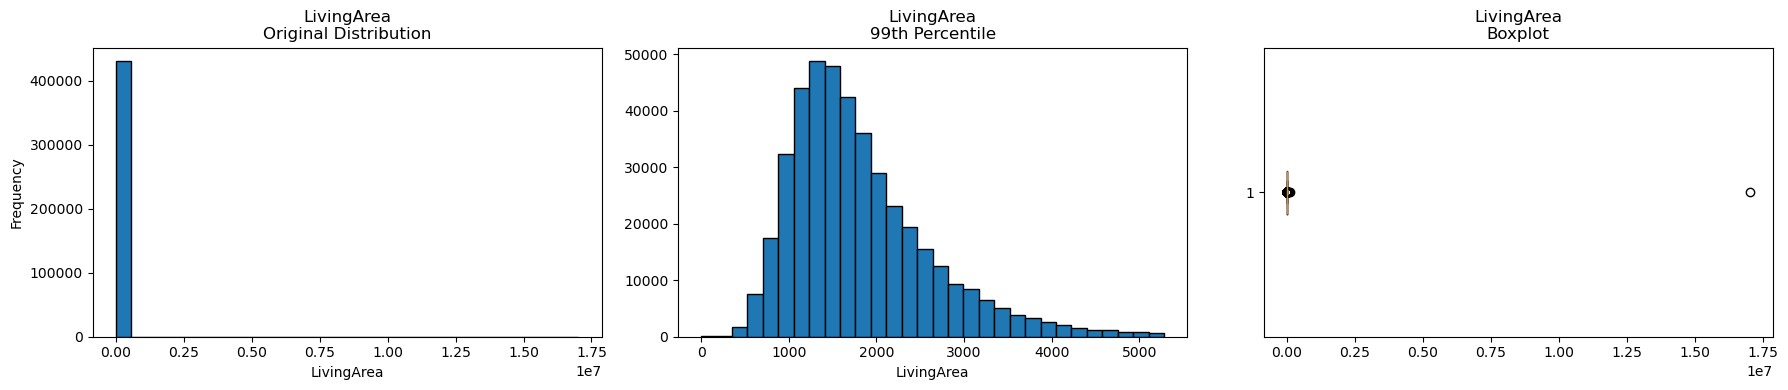

Number of Outliers (IQR): 18,900
Lower Bound: -211.50
Upper Bound: 3,680.50


LotSizeAcres
Missing Values : 33,645 (7.82%)

Summary Statistics


count    3.967830e+05
mean     6.400562e+01
std      1.568765e+04
min      0.000000e+00
1%       0.000000e+00
5%       3.000000e-02
25%      1.200000e-01
50%      1.665000e-01
75%      2.732000e-01
95%      2.840000e+00
99%      1.086431e+01
max      7.810698e+06
Name: LotSizeAcres, dtype: float64

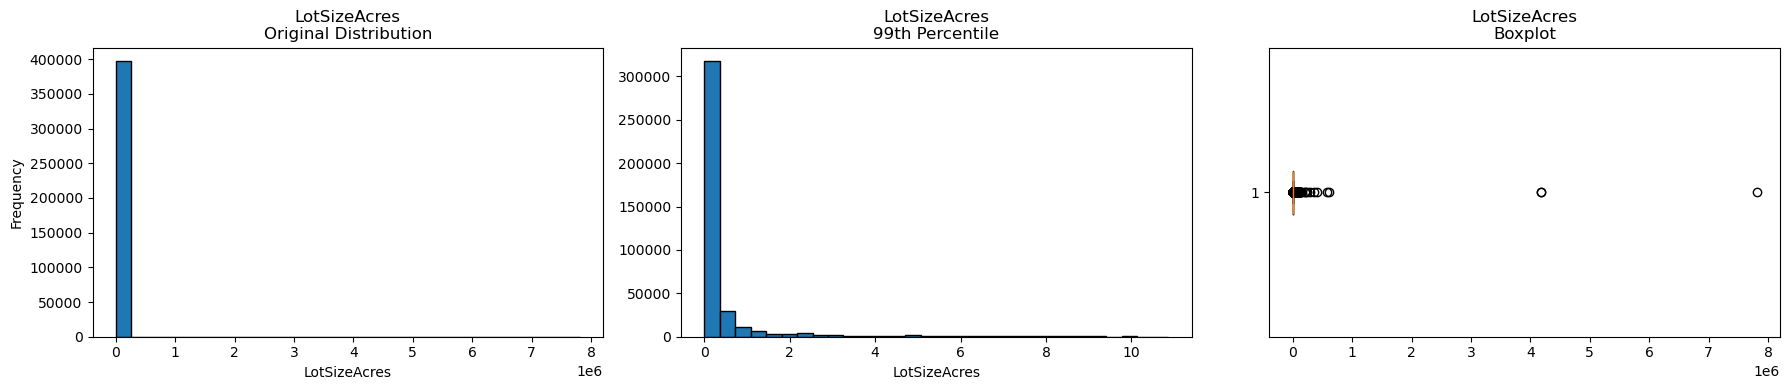

Number of Outliers (IQR): 61,734
Lower Bound: -0.11
Upper Bound: 0.50


BedroomsTotal
Missing Values : 12 (0.00%)

Summary Statistics


count    430416.000000
mean          3.203229
std           1.066805
min           0.000000
1%            1.000000
5%            2.000000
25%           3.000000
50%           3.000000
75%           4.000000
95%           5.000000
99%           6.000000
max          45.000000
Name: BedroomsTotal, dtype: float64

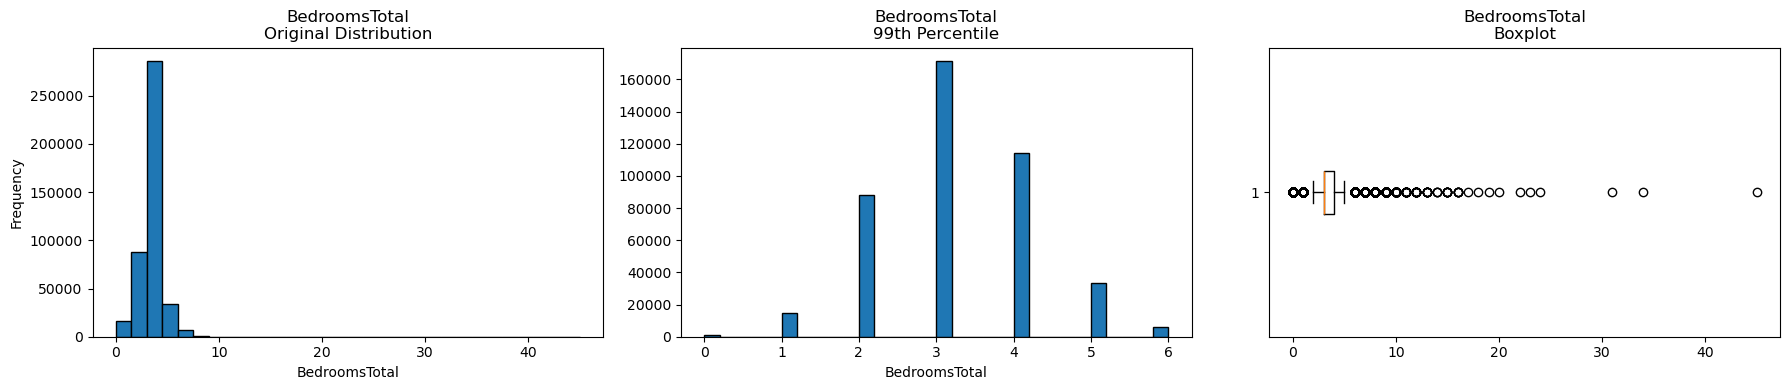

Number of Outliers (IQR): 23,579
Lower Bound: 1.50
Upper Bound: 5.50


BathroomsTotalInteger
Missing Values : 70 (0.02%)

Summary Statistics


count    430358.000000
mean          2.536651
std           1.132605
min           0.000000
1%            1.000000
5%            1.000000
25%           2.000000
50%           2.000000
75%           3.000000
95%           4.000000
99%           6.000000
max         175.000000
Name: BathroomsTotalInteger, dtype: float64

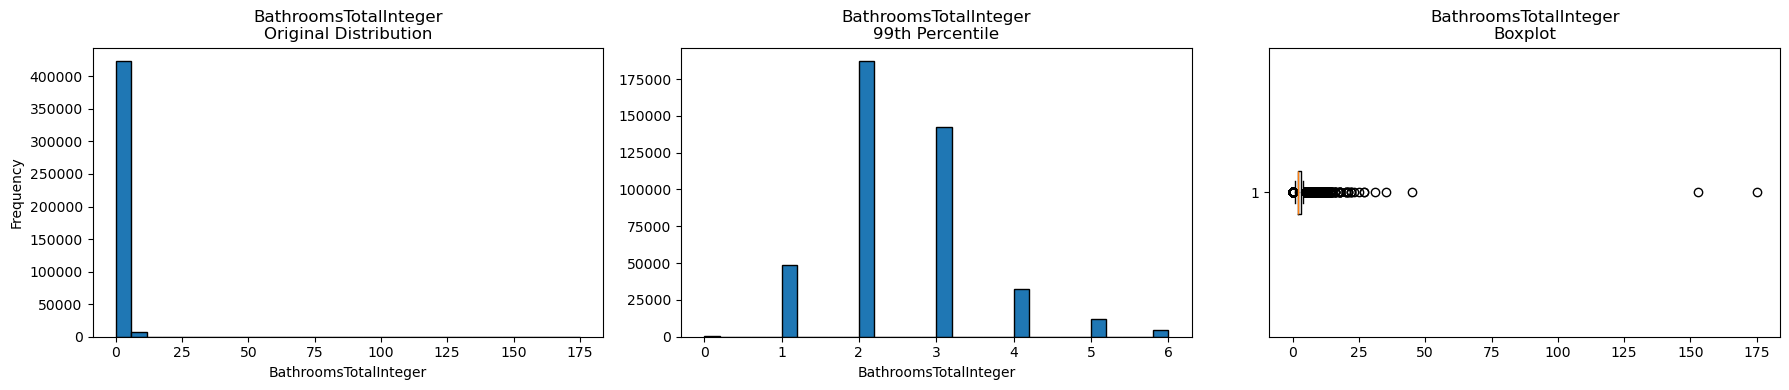

Number of Outliers (IQR): 19,878
Lower Bound: 0.50
Upper Bound: 4.50


DaysOnMarket
Missing Values : 0 (0.00%)

Summary Statistics


count    430428.000000
mean         37.333640
std          53.668161
min        -288.000000
1%            0.000000
5%            1.000000
25%           8.000000
50%          18.000000
75%          48.000000
95%         132.000000
99%         232.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

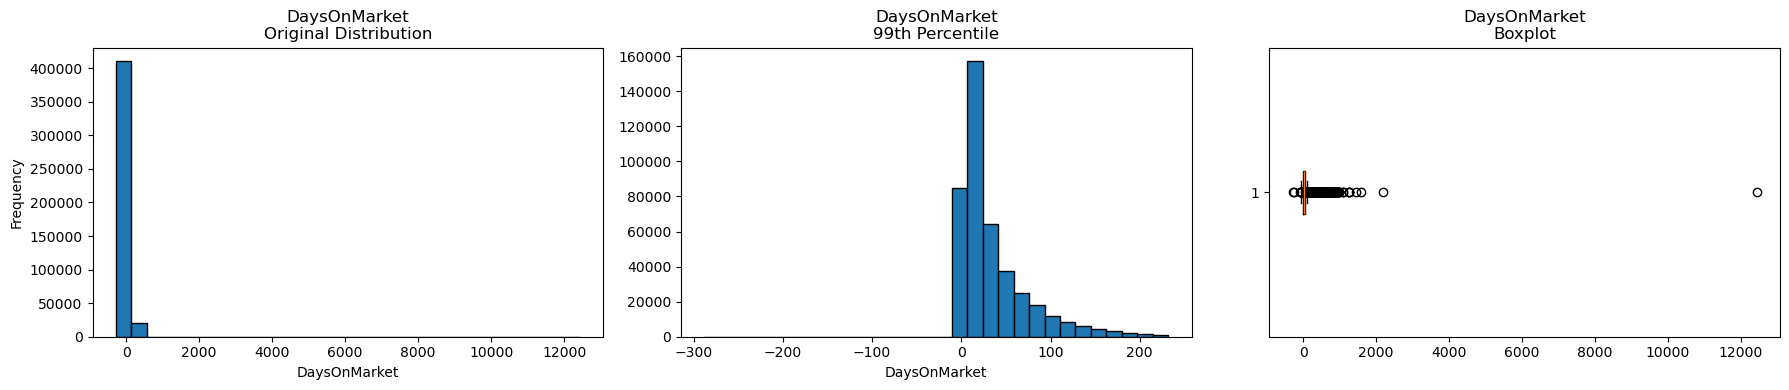

Number of Outliers (IQR): 32,988
Lower Bound: -52.00
Upper Bound: 108.00


YearBuilt
Missing Values : 382 (0.09%)

Summary Statistics


count    430046.000000
mean       1978.600413
std          26.293097
min        1776.000000
1%         1912.000000
5%         1930.000000
25%        1960.000000
50%        1979.000000
75%        1999.000000
95%        2022.000000
99%        2025.000000
max        2026.000000
Name: YearBuilt, dtype: float64

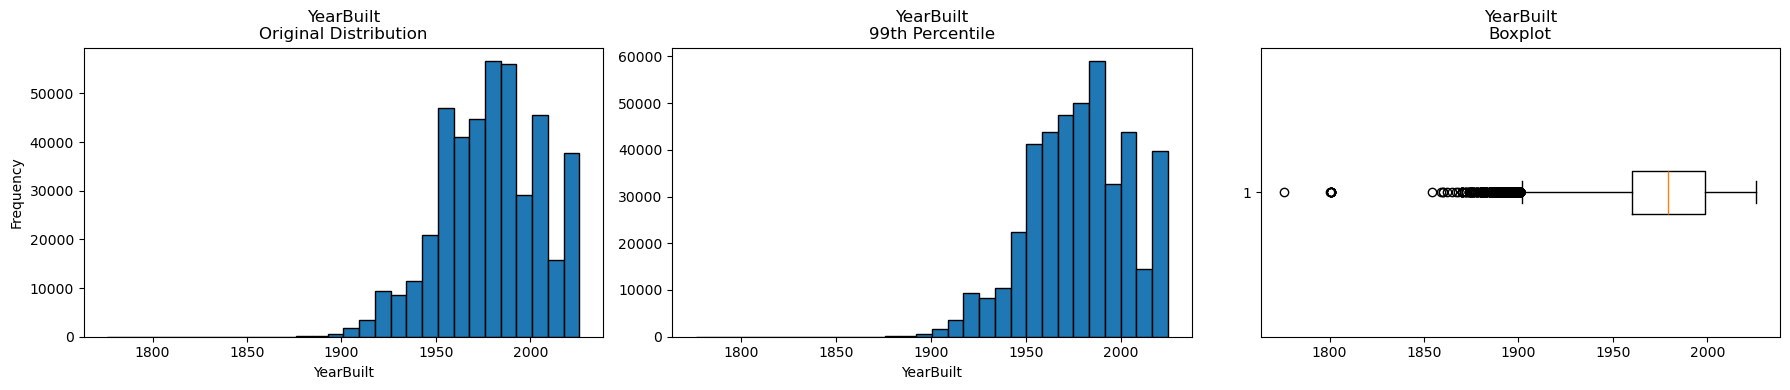

Number of Outliers (IQR): 1,015
Lower Bound: 1,901.50
Upper Bound: 2,057.50




In [26]:
import matplotlib.pyplot as plt

numeric_cols = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeAcres",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "DaysOnMarket",
    "YearBuilt",
]

for col in numeric_cols:
    print("=" * 80)
    print(col)
    print("=" * 80)

    # Missing values
    missing = sold_market_df[col].isna().sum()
    missing_pct = sold_market_df[col].isna().mean() * 100

    print(f"Missing Values : {missing:,} ({missing_pct:.2f}%)")

    # Summary statistics
    print("\nSummary Statistics")
    display(
        sold_market_df[col].describe(
            percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
        )
    )

    # IQR Outliers
    Q1 = sold_market_df[col].quantile(0.25)
    Q3 = sold_market_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = sold_market_df[
        (sold_market_df[col] < lower) | (sold_market_df[col] > upper)
    ]

    # 99th percentile for visualization
    upper_99 = sold_market_df[col].quantile(0.99)

    # Create figure
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))

    # Histogram (Original)
    ax[0].hist(sold_market_df[col].dropna(), bins=30, edgecolor="black")

    ax[0].set_title(f"{col}\nOriginal Distribution")
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Frequency")

    # Histogram (99th percentile)
    ax[1].hist(
        sold_market_df.loc[sold_market_df[col] <= upper_99, col],
        bins=30,
        edgecolor="black",
    )

    ax[1].set_title(f"{col}\n99th Percentile")
    ax[1].set_xlabel(col)

    # Boxplot
    ax[2].boxplot(sold_market_df[col].dropna(), vert=False)

    ax[2].set_title(f"{col}\nBoxplot")

    plt.tight_layout()
    plt.show()

    print(f"Number of Outliers (IQR): {len(outliers):,}")
    print(f"Lower Bound: {lower:,.2f}")
    print(f"Upper Bound: {upper:,.2f}")

    print("\n")


In [41]:
# check the reason that DaysOnMarket has negative number
sold_market_df[sold_market_df["DaysOnMarket"] < 0][
    ["ListingContractDate", "CloseDate", "DaysOnMarket"]
]


,ListingContractDate,CloseDate,DaysOnMarket
29,2023-11-17,2024-01-22,-36
1220,2024-01-08,2024-01-19,-1
17989,2024-02-24,2024-02-26,-13
18360,2024-02-16,2024-02-23,-10
29570,2023-12-12,2024-02-05,-10
35781,2023-09-25,2024-02-29,-13
38153,2024-01-30,2024-03-21,-48
38179,2024-01-11,2024-03-19,-58
38287,2024-03-03,2024-03-15,-14
46152,2024-02-07,2024-03-08,-2


In [42]:
sold_market_df["Calculated_DOM"] = (
    pd.to_datetime(sold_market_df["CloseDate"])
    - pd.to_datetime(sold_market_df["ListingContractDate"])
).dt.days
sold_market_df[["ListingContractDate", "CloseDate", "DaysOnMarket", "Calculated_DOM"]]

,ListingContractDate,CloseDate,DaysOnMarket,Calculated_DOM
0,2021-10-06,2024-01-26,777,842.0
5,2021-03-08,2024-01-05,33,1033.0
9,2021-03-08,2024-01-05,228,1033.0
28,2023-11-15,2024-01-02,0,48.0
29,2023-11-17,2024-01-22,-36,66.0
...,...,...,...,...
639828,2024-03-19,2026-05-08,768,780.0
639836,2023-12-11,2026-05-06,273,877.0
639838,2023-11-27,2026-05-15,831,900.0
639852,2022-07-19,2026-05-22,1098,1403.0


### EDA Questions
- 1. What is the Residential vs. other property type share?
- 2. What are the median and average close prices?
- 3. What does the Days on Market distribution look like?
- 4. What percentage of homes sold above vs. below list price?
- 5. Are there any apparent date consistency issues (e.g., close date before listing date)?
- 6. Which counties have the highest median prices?

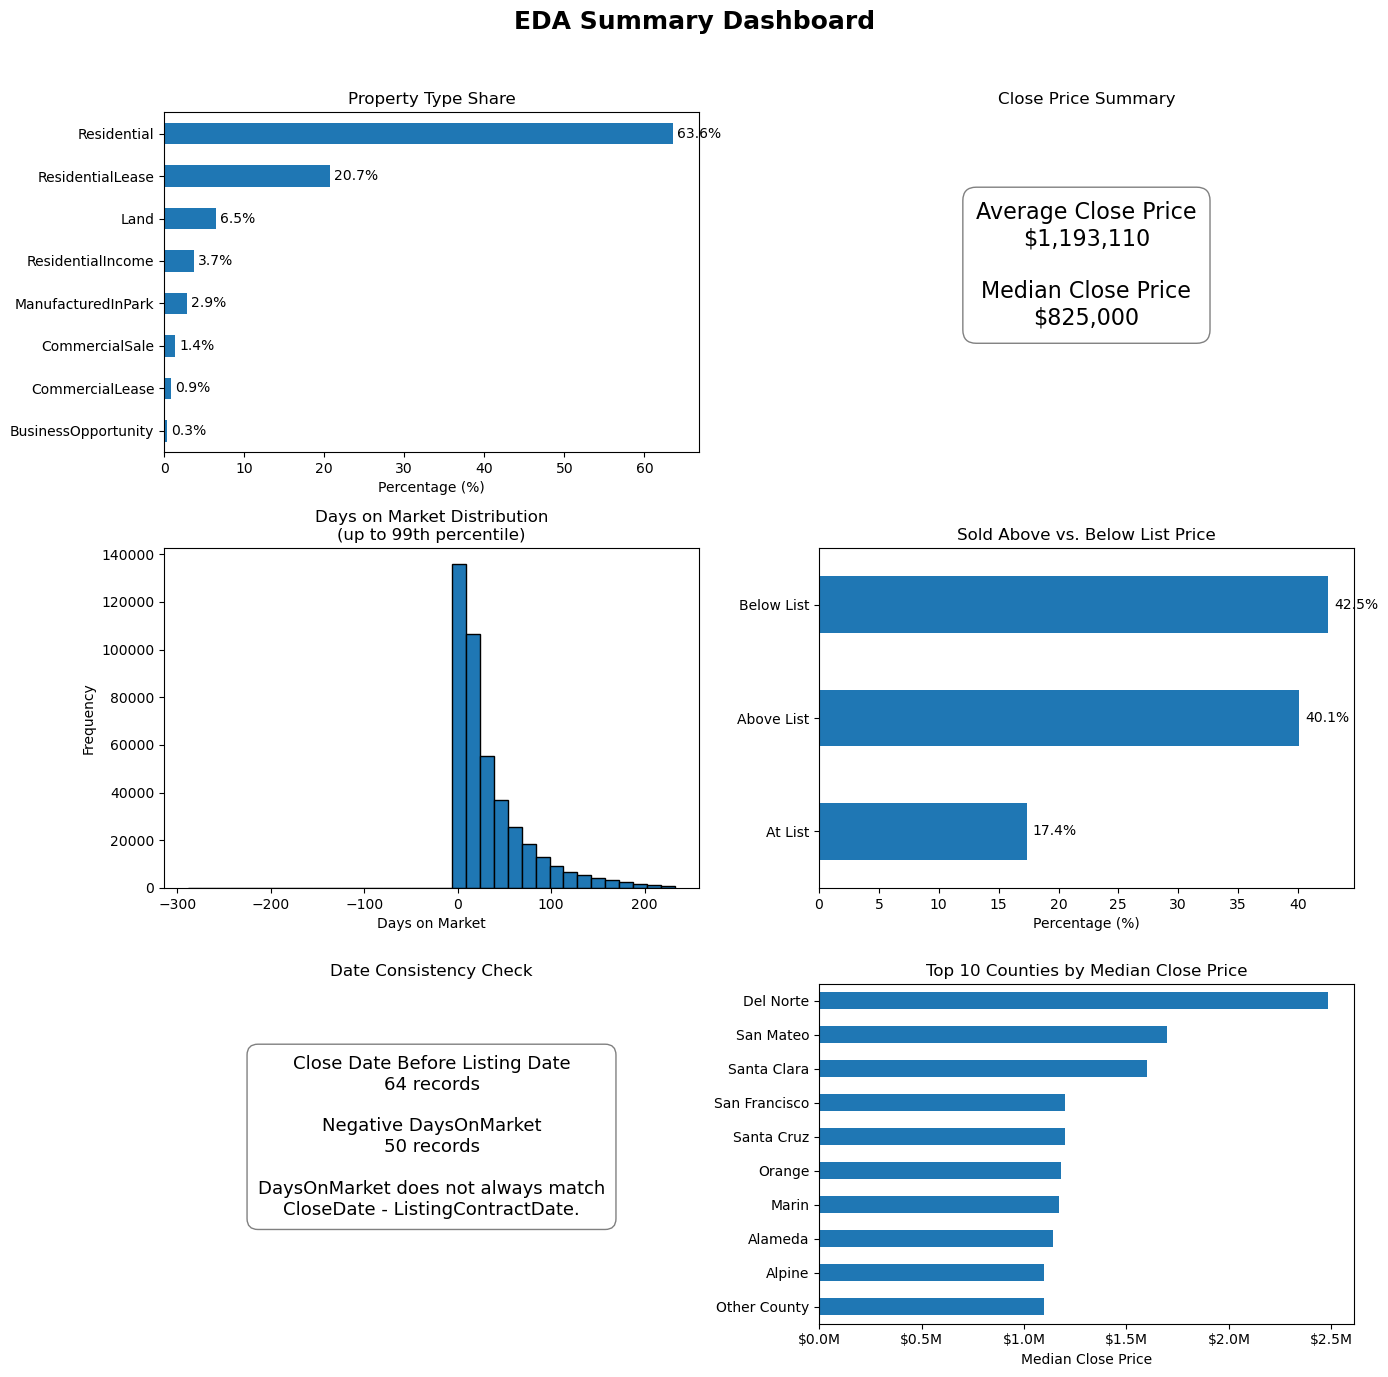

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# Prepare data

property_share = (
    listing["PropertyType"].value_counts(normalize=True).mul(100).sort_values()
)

mean_close = sold_market_df["ClosePrice"].mean()
median_close = sold_market_df["ClosePrice"].median()

dom_upper99 = sold_market_df["DaysOnMarket"].quantile(0.99)
dom_data = sold_market_df.loc[
    sold_market_df["DaysOnMarket"] <= dom_upper99, "DaysOnMarket"
]

sale_result = pd.Series(index=sold_market_df.index, dtype="object")

sale_result[sold_market_df["ClosePrice"] > sold_market_df["ListPrice"]] = "Above List"
sale_result[sold_market_df["ClosePrice"] < sold_market_df["ListPrice"]] = "Below List"
sale_result[sold_market_df["ClosePrice"] == sold_market_df["ListPrice"]] = "At List"

sale_share = sale_result.value_counts(normalize=True).mul(100).sort_values()

sold_market_df["CloseDate_dt"] = pd.to_datetime(sold_market_df["CloseDate"])
sold_market_df["ListingDate_dt"] = pd.to_datetime(sold_market_df["ListingContractDate"])

close_before_listing = (
    sold_market_df["CloseDate_dt"] < sold_market_df["ListingDate_dt"]
).sum()

negative_dom = (sold_market_df["DaysOnMarket"] < 0).sum()

top_counties = (
    sold_market_df.groupby("CountyOrParish")["ClosePrice"]
    .median()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)


def money_millions(x, pos):
    return f"${x / 1e6:.1f}M"


# Dashboard

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

fig.suptitle("EDA Summary Dashboard", fontsize=18, fontweight="bold", y=0.98)

# 1. Property Type Share
property_share.plot(kind="barh", ax=axes[0, 0])

axes[0, 0].set_title("Property Type Share")
axes[0, 0].set_xlabel("Percentage (%)")
axes[0, 0].set_ylabel("")

for i, v in enumerate(property_share):
    axes[0, 0].text(v + 0.5, i, f"{v:.1f}%", va="center")


# 2. Close Price Summary
axes[0, 1].axis("off")
axes[0, 1].set_title("Close Price Summary")

axes[0, 1].text(
    0.5,
    0.55,
    f"Average Close Price\n${mean_close:,.0f}\n\n"
    f"Median Close Price\n${median_close:,.0f}",
    ha="center",
    va="center",
    fontsize=16,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="gray"),
)


# 3. Days on Market Distribution
axes[1, 0].hist(dom_data.dropna(), bins=35, edgecolor="black")

axes[1, 0].set_title("Days on Market Distribution\n(up to 99th percentile)")
axes[1, 0].set_xlabel("Days on Market")
axes[1, 0].set_ylabel("Frequency")


# 4. Sold Above vs Below List Price
sale_share.plot(kind="barh", ax=axes[1, 1])

axes[1, 1].set_title("Sold Above vs. Below List Price")
axes[1, 1].set_xlabel("Percentage (%)")
axes[1, 1].set_ylabel("")

for i, v in enumerate(sale_share):
    axes[1, 1].text(v + 0.5, i, f"{v:.1f}%", va="center")


# 5. Date Consistency Check
axes[2, 0].axis("off")
axes[2, 0].set_title("Date Consistency Check")

axes[2, 0].text(
    0.5,
    0.55,
    f"Close Date Before Listing Date\n{close_before_listing:,} records\n\n"
    f"Negative DaysOnMarket\n{negative_dom:,} records\n\n"
    "DaysOnMarket does not always match\n"
    "CloseDate - ListingContractDate.",
    ha="center",
    va="center",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="gray"),
)


# 6. Counties with Highest Median Prices
top_counties.plot(kind="barh", ax=axes[2, 1])

axes[2, 1].set_title("Top 10 Counties by Median Close Price")
axes[2, 1].set_xlabel("Median Close Price")
axes[2, 1].set_ylabel("")
axes[2, 1].xaxis.set_major_formatter(FuncFormatter(money_millions))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
